# OMI Real Estate Quotations — Exploratory Data Analysis

This notebook performs an exploratory analysis of the **OMI (Osservatorio del Mercato Immobiliare)** dataset, published twice a year by the *Agenzia delle Entrate* (Italian Revenue Agency). OMI quotations report, for each Italian municipality and micro-zone, the minimum and maximum market price per square meter for buying (`Compr_min` / `Compr_max`) and renting (`Loc_min` / `Loc_max`) residential and commercial properties, broken down by property type and condition.

**Goals of this notebook**
- Load and consolidate the raw semiannual CSV releases into a single dataset
- Assess data quality: completeness, duplicates, and range consistency
- Describe the temporal, geographic, and categorical coverage of the data
- Explore the distribution and evolution of buying/renting quotations over time

**Data source:** [Agenzia delle Entrate — Osservatorio del Mercato Immobiliare](https://www.agenziaentrate.gov.it/portale/web/guest/schede/fabbricatiterreni/omi/banche-dati/quotazioni-immobiliari)

## Contents
1. [Setup](#1.-Setup)
2. [Load data](#2.-Load-data)
3. [Dataset overview](#3.-Dataset-overview)
4. [Temporal coverage](#4.-Temporal-coverage)
5. [Geographic coverage](#5.-Geographic-coverage)
6. [Property categories](#6.-Property-categories)
7. [OMI quotations](#7.-OMI-quotations)
8. [Summary & key takeaways](#8.-Summary-&-key-takeaways)


## 1. Setup

Standard data-analysis stack: `pandas`/`numpy` for data wrangling and `matplotlib` for visualization.

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## 2. Load data

Raw OMI releases are distributed as one semicolon-separated CSV per semester (e.g. `omi_quotations_2018_S1.csv`), expected under `data/raw/quotations/` relative to the project root. We first preview a single file to check its structure, then load and concatenate every available semester into one dataframe, tagging each row with its `reference_date`.

In [67]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent

INPUT_FOLDER = PROJECT_ROOT / "data" / "raw" / "quotations"

FILE_PREVIEW = INPUT_FOLDER / "omi_quotations_2018_S1.csv"


# =============================================================================
# LOAD DATA
# =============================================================================

df_omi_example = pd.read_csv(
    FILE_PREVIEW,
    sep=";",
    decimal=","
)

df_omi_example.head()

,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,Descr_Tipologia,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr,Loc_min,Loc_max,Sup_NL_loc,Unnamed: 21
0,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,Abitazioni civili,NORMALE,P,720.0,910.0,L,4.0,5.1,L,NaN
1,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,Box,NORMALE,P,1100.0,1600.0,L,4.4,6.2,L,NaN
2,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,Posti auto coperti,NORMALE,P,700.0,1000.0,L,2.7,3.8,L,NaN
3,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,Posti auto scoperti,NORMALE,P,600.0,800.0,L,2.5,3.3,L,NaN
4,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,Magazzini,NORMALE,P,900.0,1300.0,L,4.8,5.7,L,NaN


Load and combine every semester into a single dataframe:

In [68]:
def extract_data_from_file_name(file_name):
    """Parse the reference year/semester encoded in an OMI filename
    (e.g. 'omi_quotations_2018_S1.csv') and return it as the semester's
    end-of-period timestamp (30 June for S1, 31 December for S2).
    """
    parts = file_name.stem.split("_")

    year = int(parts[2])
    semester = parts[3]

    if semester == "S1":
        month = 6
    elif semester == "S2":
        month = 12
    else:
        raise ValueError(f"Invalid semester: {semester}")

    return pd.Timestamp(
        year=year,
        month=month,
        day=1,
    ) + pd.offsets.MonthEnd(0)


def import_csv_files_with_reference_data(file_names):
    """Read every OMI CSV file in `file_names`, tag each with its
    `reference_date`, and concatenate them into a single dataframe.
    """
    dataframes = []

    for file_name in file_names:
        df = pd.read_csv(
            file_name,
            sep=";",
            decimal=","
        )

        df["reference_date"] = extract_data_from_file_name(file_name)

        dataframes.append(df)

    return pd.concat(
        dataframes,
        ignore_index=True,
    )


file_names = [
    file for file in INPUT_FOLDER.iterdir()
    if file.suffix == ".csv"
]

df_omi = import_csv_files_with_reference_data(file_names)


## 3. Dataset overview

A first look at the consolidated dataset: shape, columns, types, missing values, and duplicate rows.

In [69]:
df_omi.head()

,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr,Loc_min,Loc_max,Sup_NL_loc,Unnamed: 21,reference_date
0,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,NORMALE,P,1150.0,1550.0,L,4.0,5.9,L,NaN,2011-12-31
1,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,NORMALE,P,1100.0,1600.0,L,4.4,6.2,L,NaN,2011-12-31
2,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,NORMALE,P,700.0,1000.0,L,2.7,3.8,L,NaN,2011-12-31
3,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,NORMALE,P,600.0,800.0,L,2.5,3.3,L,NaN,2011-12-31
4,NORD-OVEST,PIEMONTE,AL,1006003.0,A2AA,,A182,ALESSANDRIA,B,B1,...,NORMALE,P,1050.0,1300.0,L,4.8,5.7,L,NaN,2011-12-31


In [70]:
df_omi.tail()

,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr,Loc_min,Loc_max,Sup_NL_loc,Unnamed: 21,reference_date
7516490,ISOLE,SARDEGNA,SS,20090090.0,V3DT,,M301,PADRU,B,B1,...,NORMALE,P,220.0,280.0,L,1.1,1.4,L,NaN,2009-06-30
7516491,ISOLE,SARDEGNA,SS,20090090.0,V3DT,,M301,PADRU,B,B1,...,NORMALE,P,510.0,630.0,L,2.8,3.5,L,NaN,2009-06-30
7516492,ISOLE,SARDEGNA,SS,20090090.0,V3DT,,M301,PADRU,B,B1,...,NORMALE,P,510.0,580.0,L,2.6,2.9,L,NaN,2009-06-30
7516493,ISOLE,SARDEGNA,SS,20090090.0,V3DT,,M301,PADRU,B,B1,...,NORMALE,P,280.0,335.0,L,1.4,1.6,L,NaN,2009-06-30
7516494,ISOLE,SARDEGNA,SS,20090090.0,V3DT,,M301,PADRU,B,B1,...,NORMALE,P,280.0,335.0,L,1.4,1.6,L,NaN,2009-06-30


In [71]:
print(f"Number of observations: {df_omi.shape[0]:,}")
print(f"Number of variables: {df_omi.shape[1]}")

Number of observations: 7,516,495
Number of variables: 23


In [72]:
df_omi.columns.tolist()

['Area_territoriale',
 'Regione',
 'Prov',
 'Comune_ISTAT',
 'Comune_cat',
 'Sez',
 'Comune_amm',
 'Comune_descrizione',
 'Fascia',
 'Zona',
 'LinkZona',
 'Cod_Tip',
 'Descr_Tipologia',
 'Stato',
 'Stato_prev',
 'Compr_min',
 'Compr_max',
 'Sup_NL_compr',
 'Loc_min',
 'Loc_max',
 'Sup_NL_loc',
 'Unnamed: 21',
 'reference_date']

In [73]:
df_omi.info()

<class 'pandas.DataFrame'>
RangeIndex: 7516495 entries, 0 to 7516494
Data columns (total 23 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Area_territoriale   str           
 1   Regione             str           
 2   Prov                str           
 3   Comune_ISTAT        float64       
 4   Comune_cat          str           
 5   Sez                 str           
 6   Comune_amm          str           
 7   Comune_descrizione  str           
 8   Fascia              str           
 9   Zona                str           
 10  LinkZona            str           
 11  Cod_Tip             int64         
 12  Descr_Tipologia     str           
 13  Stato               str           
 14  Stato_prev          str           
 15  Compr_min           float64       
 16  Compr_max           float64       
 17  Sup_NL_compr        str           
 18  Loc_min             float64       
 19  Loc_max             float64       
 20  Sup_NL_loc   

**Missing values per column:**

In [74]:
missing_summary = (
    df_omi.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(df_omi)
    * 100
)

missing_summary.sort_values(
    "missing_count",
    ascending=False,
)

,missing_count,missing_pct
Unnamed: 21,7516495,100.000000
Loc_min,547250,7.280654
Loc_max,547250,7.280654
Sup_NL_loc,522050,6.945391
Prov,154178,2.051195
Stato,96357,1.281941
Compr_min,1558,0.020728
Compr_max,1558,0.020728
Sup_NL_compr,1558,0.020728
Comune_ISTAT,37,0.000492


**Exact duplicate rows:**

In [75]:
df_omi.duplicated().sum()

print(
    f"Duplicate rows: {df_omi.duplicated().sum():,}"
)

Duplicate rows: 0


> **Takeaway:** the consolidated dataset holds **7,516,495 observations** across **23 variables**, spanning the full OMI release history, with **no exact duplicate rows**. Missing values are concentrated in the rental quotation columns (`Loc_min`/`Loc_max`), consistent with properties that are not commonly rented in a given zone.

## 4. Temporal coverage

OMI data is released twice a year (semesters ending in June and December). Here we check the time span covered, the number of observations per semester, and whether any semester is missing from the raw files.

In [76]:
print(f"Start date: {df_omi['reference_date'].min().date()}")
print(f"End date:   {df_omi['reference_date'].max().date()}")

Start date: 2004-06-30
End date:   2025-12-31


In [77]:
reference_dates = (
    df_omi["reference_date"]
    .drop_duplicates()
    .sort_values()
)

reference_dates

3568436   2004-06-30
6814484   2004-12-31
5425216   2005-06-30
2211727   2005-12-31
6265770   2006-06-30
6989174   2006-12-31
6633373   2007-06-30
1867672   2007-12-31
665949    2008-06-30
6082390   2008-12-31
7332608   2009-06-30
4920111   2009-12-31
2389679   2010-06-30
4224728   2010-12-31
847717    2011-06-30
0         2011-12-31
6445470   2012-06-30
4732044   2012-12-31
1196013   2013-06-30
3221044   2013-12-31
5921380   2014-06-30
2736627   2014-12-31
7170228   2015-06-30
5601431   2015-12-31
3901685   2016-06-30
2049576   2016-12-31
1034013   2017-06-30
5105450   2017-12-31
1545146   2018-06-30
1383894   2018-12-31
4410711   2019-06-30
3741159   2019-12-31
2899383   2020-06-30
186650    2020-12-31
3407323   2021-06-30
2575404   2021-12-31
4571094   2022-06-30
1706782   2022-12-31
504993    2023-06-30
3060055   2023-12-31
4063878   2024-06-30
5267531   2024-12-31
5763793   2025-06-30
347385    2025-12-31
Name: reference_date, dtype: datetime64[us]

In [78]:
observations_by_date = (
    df_omi["reference_date"]
    .value_counts()
    .sort_index()
)

observations_by_date

reference_date
2004-06-30    172723
2004-12-31    174690
2005-06-30    176215
2005-12-31    177952
2006-06-30    179700
2006-12-31    181054
2007-06-30    181111
2007-12-31    181904
2008-06-30    181768
2008-12-31    183380
2009-06-30    183887
2009-12-31    185339
2010-06-30    185725
2010-12-31    185983
2011-06-30    186296
2011-12-31    186650
2012-06-30    187903
2012-12-31    188067
2013-06-30    187881
2013-12-31    186279
2014-06-30    161010
2014-12-31    162756
2015-06-30    162380
2015-12-31    162362
2016-06-30    162193
2016-12-31    162151
2017-06-30    162000
2017-12-31    162081
2018-06-30    161636
2018-12-31    161252
2019-06-30    160383
2019-12-31    160526
2020-06-30    160672
2020-12-31    160735
2021-06-30    161113
2021-12-31    161223
2022-06-30    160950
2022-12-31    160890
2023-06-30    160956
2023-12-31    160989
2024-06-30    160850
2024-12-31    157685
2025-06-30    157587
2025-12-31    157608
Name: count, dtype: int64

Number of observations per reference semester:

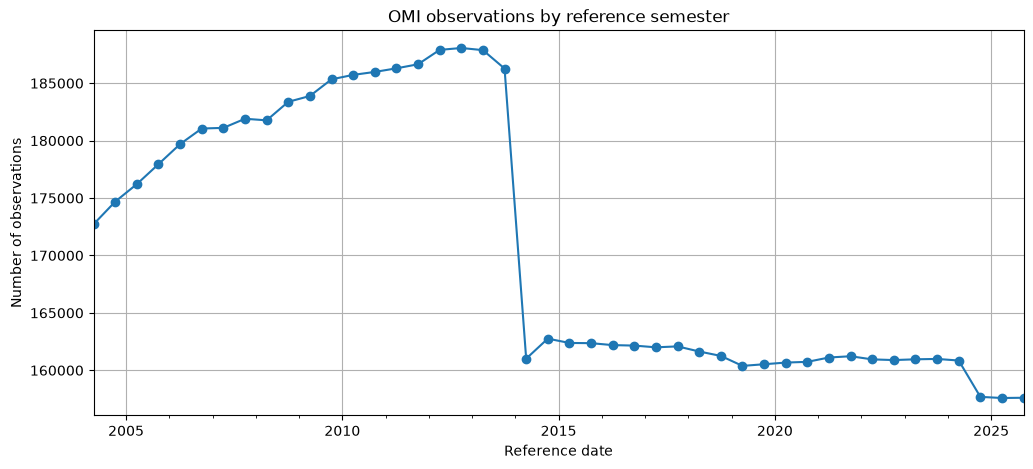

In [79]:
observations_by_date.plot(
    figsize=(12, 5),
    marker="o",
)

plt.title("OMI observations by reference semester")
plt.xlabel("Reference date")
plt.ylabel("Number of observations")
plt.grid(True)
plt.show()

Build the theoretical set of semiannual release dates and compare it against the ones actually present, to spot gaps:

In [80]:
start_date = df_omi['reference_date'].min().date()
end_date = df_omi['reference_date'].max().date()

expected_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="6ME",
)

expected_dates

DatetimeIndex(['2004-06-30', '2004-12-31', '2005-06-30', '2005-12-31',
               '2006-06-30', '2006-12-31', '2007-06-30', '2007-12-31',
               '2008-06-30', '2008-12-31', '2009-06-30', '2009-12-31',
               '2010-06-30', '2010-12-31', '2011-06-30', '2011-12-31',
               '2012-06-30', '2012-12-31', '2013-06-30', '2013-12-31',
               '2014-06-30', '2014-12-31', '2015-06-30', '2015-12-31',
               '2016-06-30', '2016-12-31', '2017-06-30', '2017-12-31',
               '2018-06-30', '2018-12-31', '2019-06-30', '2019-12-31',
               '2020-06-30', '2020-12-31', '2021-06-30', '2021-12-31',
               '2022-06-30', '2022-12-31', '2023-06-30', '2023-12-31',
               '2024-06-30', '2024-12-31', '2025-06-30', '2025-12-31'],
              dtype='datetime64[s]', freq='6ME')

In [81]:
years = range(
    start_date.year,
    end_date.year + 1,
)

expected_dates = []

for year in years:
    expected_dates.extend(
        [
            pd.Timestamp(year=year, month=6, day=30),
            pd.Timestamp(year=year, month=12, day=31),
        ]
    )

expected_dates = pd.DatetimeIndex(expected_dates)

missing_dates = expected_dates.difference(
    reference_dates
)

missing_dates

DatetimeIndex([], dtype='datetime64[us]', freq=None)

In [82]:
temporal_summary = pd.DataFrame({
    "reference_date": reference_dates,
    "observations": [
        observations_by_date.get(date, 0)
        for date in reference_dates
    ],
})

temporal_summary

,reference_date,observations
3568436,2004-06-30,172723
6814484,2004-12-31,174690
5425216,2005-06-30,176215
2211727,2005-12-31,177952
6265770,2006-06-30,179700
6989174,2006-12-31,181054
6633373,2007-06-30,181111
1867672,2007-12-31,181904
665949,2008-06-30,181768
6082390,2008-12-31,183380


> **Takeaway:** the dataset covers **2004-06-30 to 2025-12-31** — 44 semesters of OMI releases — with observation counts per semester detailed in `temporal_summary` above.

## 5. Geographic coverage

OMI quotations are reported at a fine-grained geographic level: region → province → municipality → OMI micro-zone. We check the granularity and coverage at each level.

In [83]:
n_regions = df_omi["Regione"].nunique()

print(f"Number of regions: {n_regions}")

Number of regions: 20


In [84]:
regions = (
    df_omi["Regione"]
    .dropna()
    .sort_values()
    .unique()
)

regions

<ArrowStringArray>
[                      'ABRUZZO',                    'BASILICATA',
                      'CALABRIA',                      'CAMPANIA',
                'EMILIA-ROMAGNA',         'FRIULI-VENEZIA GIULIA',
                         'LAZIO',                       'LIGURIA',
                     'LOMBARDIA',                        'MARCHE',
                        'MOLISE',                      'PIEMONTE',
                        'PUGLIA',                      'SARDEGNA',
                       'SICILIA',                       'TOSCANA',
           'TRENTINO-ALTO ADIGE',                        'UMBRIA',
 'VALLE D'AOSTA/VALLE`E D'AOSTE',                        'VENETO']
Length: 20, dtype: str

Observations by region:

In [85]:
observations_by_region = (
    df_omi["Regione"]
    .value_counts()
    .sort_values(ascending=False)
)

observations_by_region

Regione
LOMBARDIA                        1199087
PIEMONTE                          725278
CAMPANIA                          686636
VENETO                            520534
SICILIA                           431450
TOSCANA                           429040
EMILIA-ROMAGNA                    422007
CALABRIA                          381705
ABRUZZO                           377414
PUGLIA                            342003
LAZIO                             315825
LIGURIA                           305410
MARCHE                            304044
TRENTINO-ALTO ADIGE               282401
FRIULI-VENEZIA GIULIA             221095
SARDEGNA                          214284
BASILICATA                        144224
UMBRIA                            116446
MOLISE                             57112
VALLE D'AOSTA/VALLE`E D'AOSTE      40500
Name: count, dtype: int64

In [86]:
n_provinces = df_omi["Prov"].nunique()

print(f"Number of provinces: {n_provinces}")

Number of provinces: 102


Top 20 provinces by number of observations:

In [87]:
observations_by_province = (
    df_omi["Prov"]
    .value_counts()
    .sort_values(ascending=False)
)

observations_by_province.head(20)

Prov
AV    294980
MI    223244
BS    221440
LE    175696
RC    174044
BZ    169498
CN    168081
TO    161026
SA    156410
BG    143928
TV    141606
AP    139051
UD    126946
AQ    126652
SI    123077
SO    122907
VI    117938
GE    116076
CH    113876
TN    112903
Name: count, dtype: int64

In [88]:
n_municipalities = df_omi["Comune_descrizione"].nunique()

print(f"Number of municipalities: {n_municipalities}")

Number of municipalities: 8220


Top 20 municipalities by number of observations:

In [89]:
observations_by_municipality = (
    df_omi["Comune_descrizione"]
    .value_counts()
    .sort_values(ascending=False)
)

observations_by_municipality.head(20)

Comune_descrizione
ROMA                   62637
GENOVA                 36765
NAPOLI                 27647
MILANO                 27284
PALERMO                17822
BOLOGNA                14642
TORINO                 14236
AVELLINO               14192
SIENA                  13261
BARI                   11819
REGGIO DI  CALABRIA    11380
BRESCIA                11323
ASCOLI PICENO          10282
CATANIA                10260
FIRENZE                10220
CATANZARO              10217
FERMO                  10052
BERGAMO                10020
TERAMO                  9332
BOLZANO .BOZEN.         9144
Name: count, dtype: int64

In [90]:
n_omi_zones = df_omi["Zona"].nunique()

print(f"Number of OMI zones: {n_omi_zones}")

Number of OMI zones: 393


Top 20 OMI zones by number of observations:

In [91]:
observations_by_zone = (
    df_omi["Zona"]
    .value_counts()
    .sort_values(ascending=False)
)

observations_by_zone.head(20)

Zona
B1    2360331
D1    1125942
R1     630582
E1     550865
C1     393952
B2     363906
D2     296582
E2     243971
E3     123901
D3     122282
B3     109565
C2     103355
R2      95099
E4      74502
B       68994
D4      67264
C3      49155
E5      42382
R3      40836
D5      39888
Name: count, dtype: int64

Sanity check: are OMI zone codes unique within a municipality, or reused across municipalities?

In [92]:
municipality_zone = (
    df_omi["Comune_descrizione"].astype(str)
    + "_"
    + df_omi["Zona"].astype(str)
)

municipality_zone.nunique()

42072

`Fascia` (band) is a further geographic sub-classification used for larger cities:

In [93]:
df_omi["Fascia"].nunique()

5

In [94]:
df_omi["Fascia"].dropna().unique()

<ArrowStringArray>
['B', 'C', 'D', 'E', 'R']
Length: 5, dtype: str

In [95]:
df_omi["Fascia"].value_counts()

Fascia
B    2996662
D    1826450
E    1194493
R     828750
C     670140
Name: count, dtype: int64

Summary of geographic granularity:

In [96]:
geographic_summary = pd.DataFrame({
    "geographic_level": [
        "Regions",
        "Provinces",
        "Municipalities",
        "OMI zones",
        "Municipality × OMI zone",
    ],
    "unique_values": [
        df_omi["Regione"].nunique(),
        df_omi["Prov"].nunique(),
        df_omi["Comune_descrizione"].nunique(),
        df_omi["Zona"].nunique(),
        municipality_zone.nunique(),
    ],
})

geographic_summary

,geographic_level,unique_values
0,Regions,20
1,Provinces,102
2,Municipalities,8220
3,OMI zones,393
4,Municipality × OMI zone,42072


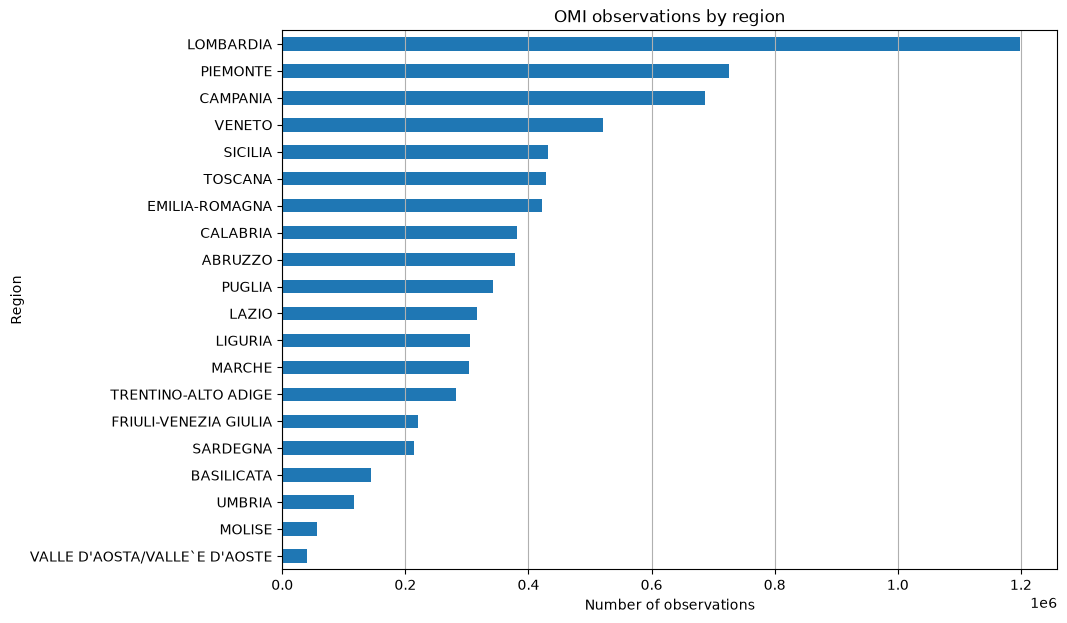

In [97]:
observations_by_region.sort_values().plot(
    kind="barh",
    figsize=(10, 7),
)

plt.title("OMI observations by region")
plt.xlabel("Number of observations")
plt.ylabel("Region")
plt.grid(axis="x")
plt.show()

> **Takeaway:** coverage spans **20 regions**, **102 provinces**, **8,220 municipalities** and **393 distinct OMI zone codes** (reused across municipalities — see `geographic_summary` for the true number of unique municipality × zone combinations).

## 6. Property categories

Each OMI observation refers to a specific property type (`Descr_Tipologia`, e.g. apartments, offices, shops) and condition (`Stato`, e.g. normal, poor, excellent). We examine both dimensions and how they relate to each other and to the timeline.

In [98]:
n_property_types = df_omi["Descr_Tipologia"].nunique()

print(f"Number of property types: {n_property_types}")

Number of property types: 19


Observations by property type:

In [99]:
observations_by_property_type = (
    df_omi["Descr_Tipologia"]
    .value_counts()
    .sort_values(ascending=False)
)

observations_by_property_type

Descr_Tipologia
Abitazioni civili                            1183089
Ville e Villini                               853424
Negozi                                        788893
Box                                           782999
Abitazioni di tipo economico                  765963
Magazzini                                     662623
Uffici                                        592632
Laboratori                                    561008
Capannoni tipici                              428538
Capannoni industriali                         258369
Autorimesse                                   231143
Posti auto scoperti                           166522
Posti auto coperti                            163722
Centri commerciali                             28370
Uffici strutturati                             21399
Abitazioni tipiche dei luoghi                  14287
Abitazioni signorili                            8355
Pensioni e assimilati                           5142
Fabbricati e locali per eserci

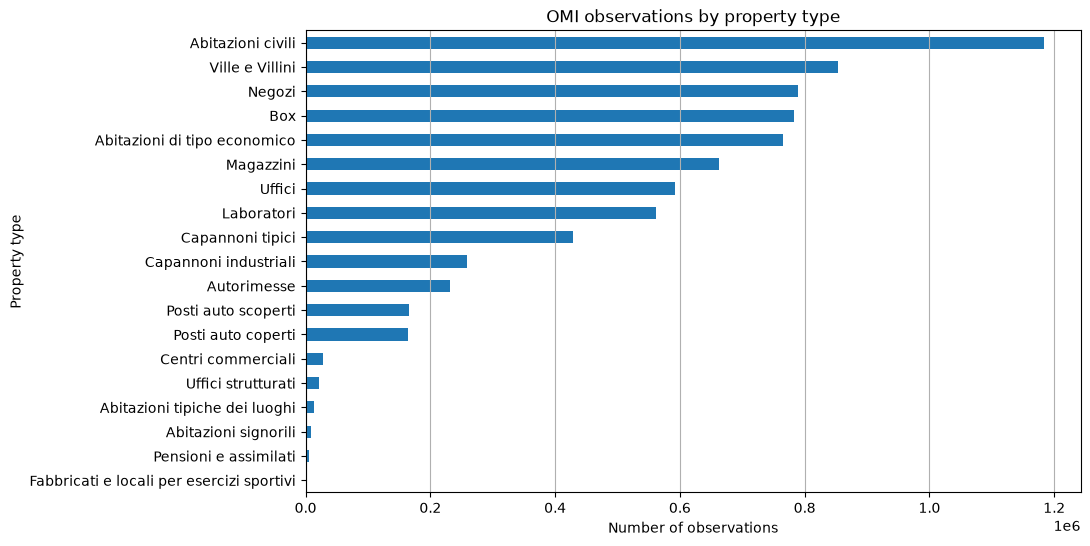

In [100]:
observations_by_property_type.sort_values().plot(
    kind="barh",
    figsize=(10, 6),
)

plt.title("OMI observations by property type")
plt.xlabel("Number of observations")
plt.ylabel("Property type")
plt.grid(axis="x")
plt.show()

Check the mapping between property type code (`Cod_Tip`) and its description:

In [101]:
property_type_mapping = (
    df_omi[
        ["Cod_Tip", "Descr_Tipologia"]
    ]
    .drop_duplicates()
    .sort_values("Cod_Tip")
)

property_type_mapping

,Cod_Tip,Descr_Tipologia
12,1,Ville e Villini
5,5,Negozi
6,6,Uffici
17,7,Capannoni tipici
16,8,Capannoni industriali
4,9,Magazzini
7,10,Laboratori
1,13,Box
2,14,Posti auto coperti
3,15,Posti auto scoperti


Confirm each type code always maps to the same description (i.e. no inconsistent labeling over time):

In [102]:
type_code_consistency = (
    df_omi
    .groupby("Cod_Tip")["Descr_Tipologia"]
    .nunique()
)

type_code_consistency.value_counts()

Descr_Tipologia
1    19
Name: count, dtype: int64

In [103]:
type_code_consistency[
    type_code_consistency > 1
]

Series([], Name: Descr_Tipologia, dtype: int64)

In [104]:
n_states = df_omi["Stato"].nunique()

print(f"Number of property states: {n_states}")

Number of property states: 3


In [105]:
df_omi["Stato"].value_counts(dropna=False)

Stato
NORMALE     6442670
OTTIMO       928104
NaN           96357
SCADENTE      49364
Name: count, dtype: int64

`Stato_prev` records the property condition of the *previous* release, useful to track condition changes over time:

In [106]:
df_omi["Stato_prev"].value_counts(dropna=False)

Stato_prev
P      6790189
        726300
NaN          4
0            2
Name: count, dtype: int64

Cross-tabulation of property type × condition:

In [107]:
property_type_state = pd.crosstab(
    df_omi["Descr_Tipologia"],
    df_omi["Stato"],
)

property_type_state

Stato,NORMALE,OTTIMO,SCADENTE
Descr_Tipologia,,,
Abitazioni civili,933020,238034,12009
Abitazioni di tipo economico,672317,81042,12577
Abitazioni signorili,6200,2155,0
Abitazioni tipiche dei luoghi,5564,1347,7376
Autorimesse,210840,1,0
Box,729366,15,0
Capannoni industriali,232052,25547,699
Capannoni tipici,360453,66298,1601
Centri commerciali,22718,5640,6


Property type observations over time:

In [108]:
property_type_by_date = pd.crosstab(
    df_omi["reference_date"],
    df_omi["Descr_Tipologia"],
)

property_type_by_date

Descr_Tipologia,Abitazioni civili,Abitazioni di tipo economico,Abitazioni signorili,Abitazioni tipiche dei luoghi,Autorimesse,Box,Capannoni industriali,Capannoni tipici,Centri commerciali,Fabbricati e locali per esercizi sportivi,Laboratori,Magazzini,Negozi,Pensioni e assimilati,Posti auto coperti,Posti auto scoperti,Uffici,Uffici strutturati,Ville e Villini
reference_date,,,,,,,,,,,,,,,,,,,
2004-06-30,24062,14176,98,58,6851,19058,6437,9782,686,0,13553,15236,19393,12,4470,4389,15632,525,18305
2004-12-31,24770,14753,109,86,6822,19112,6500,9807,690,0,13497,15362,19416,12,4453,4412,15666,539,18684
2005-06-30,25087,15456,113,106,6758,18931,6484,10010,676,0,13675,15593,19491,12,4384,4345,15563,556,18975
2005-12-31,25467,15877,122,155,6741,18934,6493,10220,711,0,13853,15782,19455,13,4417,4400,15414,561,19337
2006-06-30,26248,16347,134,165,6753,18948,6381,10145,715,1,13742,15710,19279,140,4549,4556,15301,567,20019
2006-12-31,26768,16935,144,260,6662,18935,6420,10279,708,1,13733,15824,19326,141,4484,4487,15176,553,20218
2007-06-30,26742,17141,147,261,6622,18922,6409,10245,707,1,13735,15826,19275,142,4497,4523,15085,564,20267
2007-12-31,26961,17354,149,362,6594,18920,6335,10304,703,1,13837,15822,19268,146,4495,4519,15183,564,20387
2008-06-30,27023,17388,153,370,6565,18944,6225,10355,706,1,13669,15816,19238,147,4487,4512,15157,599,20413


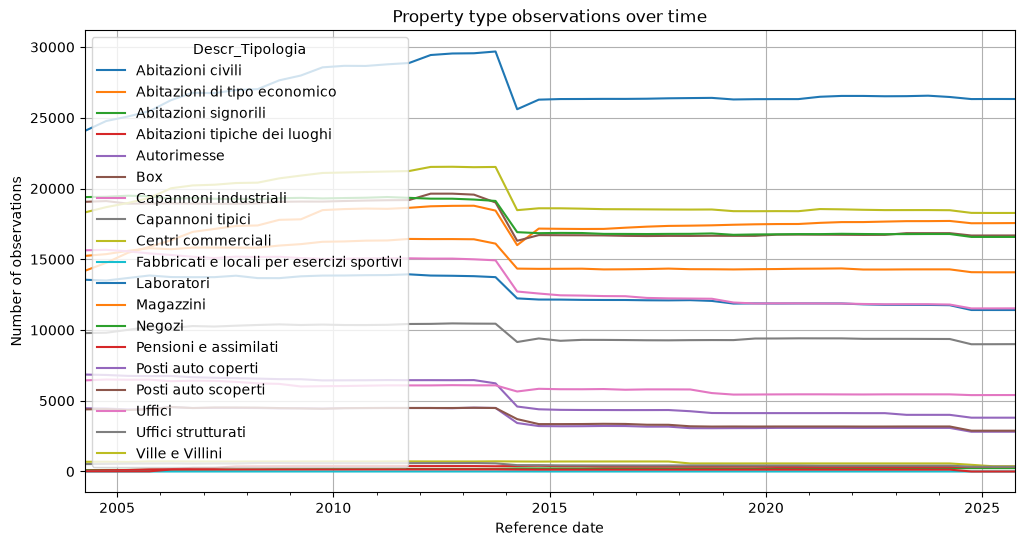

In [109]:
property_type_by_date.plot(
    figsize=(12, 6),
)

plt.title("Property type observations over time")
plt.xlabel("Reference date")
plt.ylabel("Number of observations")
plt.grid(True)
plt.show()

> **Takeaway:** the dataset distinguishes **19 property types** and **3 condition states** (`Stato`), with type codes mapping consistently to a single description across all releases.

## 7. OMI quotations

The core of the dataset: minimum/maximum buying (`Compr_*`) and renting (`Loc_*`) prices per square meter. We check their distribution, validity (min ≤ max), and derive midpoint and range features before looking at how quotations vary by property condition and over time.

In [110]:
quotation_columns = [
    "Compr_min",
    "Compr_max",
    "Loc_min",
    "Loc_max",
]

df_omi[quotation_columns].dtypes

Compr_min    float64
Compr_max    float64
Loc_min      float64
Loc_max      float64
dtype: object

Summary statistics for the raw quotation columns:

In [111]:
df_omi[quotation_columns].describe()

,Compr_min,Compr_max,Loc_min,Loc_max
count,7.514937e+06,7.514937e+06,6.969245e+06,6.969245e+06
mean,7.929877e+02,1.070952e+03,3.166197e+00,4.366805e+00
std,6.184122e+02,8.488519e+02,2.404697e+00,3.404138e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+02,5.500000e+02,1.700000e+00,2.300000e+00
50%,6.300000e+02,8.500000e+02,2.600000e+00,3.500000e+00
75%,1.000000e+03,1.330000e+03,4.000000e+00,5.400000e+00
max,2.000000e+04,3.336000e+04,1.683000e+02,5.090000e+02


Missing values in the quotation columns:

In [112]:
quotation_missing = (
    df_omi[quotation_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

quotation_missing["missing_pct"] = (
    quotation_missing["missing_count"]
    / len(df_omi)
    * 100
)

quotation_missing

,missing_count,missing_pct
Compr_min,1558,0.020728
Compr_max,1558,0.020728
Loc_min,547250,7.280654
Loc_max,547250,7.280654


Consistency check: is `min` ever greater than `max`?

In [113]:
invalid_compr = df_omi[
    df_omi["Compr_min"] > df_omi["Compr_max"]
]

print(f"Invalid buying quotation ranges: {len(invalid_compr):,}")

Invalid buying quotation ranges: 0


In [114]:
invalid_loc = df_omi[
    df_omi["Loc_min"] > df_omi["Loc_max"]
]

print(f"Invalid rental quotation ranges: {len(invalid_loc):,}")

Invalid rental quotation ranges: 230


> **Takeaway:** buying ranges (`Compr_min`/`Compr_max`) are always internally consistent, while **230 rows** have an inverted rental range (`Loc_min` > `Loc_max`) — worth flagging for cleaning in downstream analyses.

Derive midpoint and range features for buying and renting quotations:

In [115]:
df_omi["Compr_mid"] = (
    df_omi["Compr_min"] + df_omi["Compr_max"]
) / 2

In [116]:
df_omi["Loc_mid"] = (
    df_omi["Loc_min"] + df_omi["Loc_max"]
) / 2

In [117]:
df_omi["Compr_range"] = (
    df_omi["Compr_max"] - df_omi["Compr_min"]
)

df_omi["Loc_range"] = (
    df_omi["Loc_max"] - df_omi["Loc_min"]
)

Distribution of the derived midpoint quotations:

In [118]:
df_omi["Compr_mid"].describe()

count    7.514937e+06
mean     9.319697e+02
std      7.299860e+02
min      0.000000e+00
25%      4.750000e+02
50%      7.500000e+02
75%      1.155000e+03
max      2.502000e+04
Name: Compr_mid, dtype: float64

In [119]:
df_omi["Loc_mid"].describe()

count    6.969244e+06
mean     3.766501e+00
std      2.887628e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.050000e+00
75%      4.650000e+00
max      2.565000e+02
Name: Loc_mid, dtype: float64

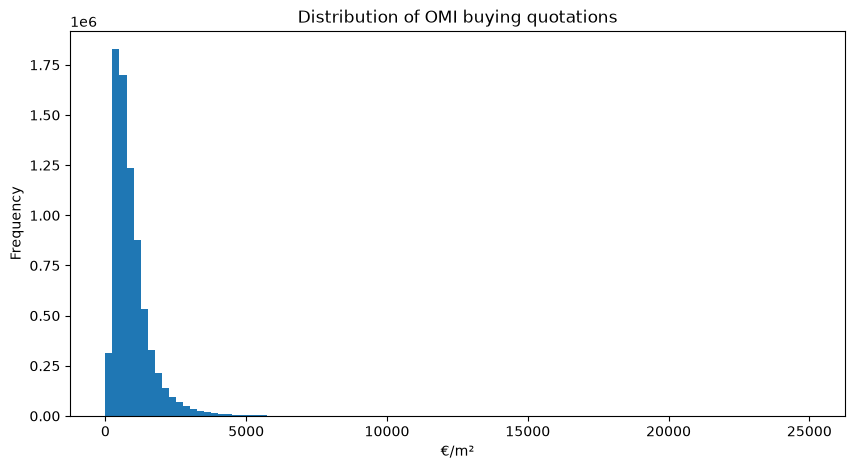

In [120]:
df_omi["Compr_mid"].plot(
    kind="hist",
    bins=100,
    figsize=(10, 5),
)

plt.title("Distribution of OMI buying quotations")
plt.xlabel("€/m²")
plt.ylabel("Frequency")
plt.show()

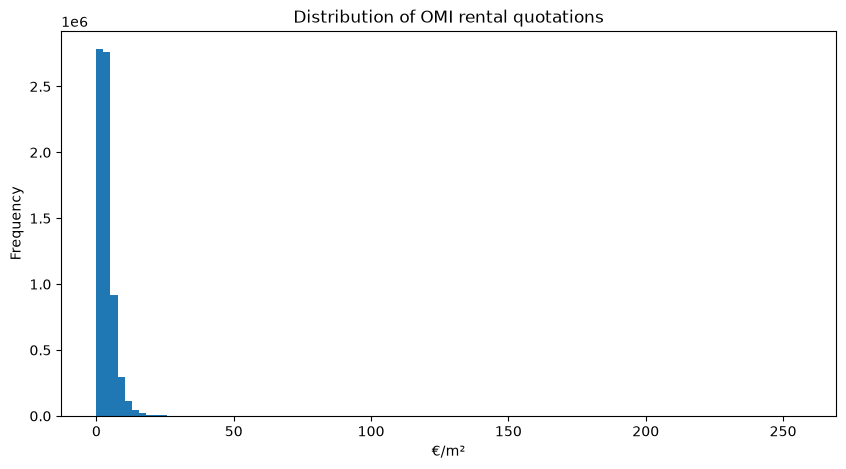

In [121]:
df_omi["Loc_mid"].plot(
    kind="hist",
    bins=100,
    figsize=(10, 5),
)

plt.title("Distribution of OMI rental quotations")
plt.xlabel("€/m²")
plt.ylabel("Frequency")
plt.show()

Buying quotations by property condition:

In [122]:
df_omi.groupby("Stato")[
    ["Compr_min", "Compr_max"]
].describe()

Compr_min                                                        \
              count         mean         std   min    25%     50%     75%   
Stato                                                                       
NORMALE   6441261.0   742.980842  564.530298   0.0  390.0   600.0   920.0   
OTTIMO     927966.0  1171.471861  826.568034   0.0  620.0  1000.0  1500.0   
SCADENTE    49353.0   808.294106  581.710381  28.0  400.0   700.0  1000.0   

                   Compr_max                                                 \
              max      count         mean          std   min    25%     50%   
Stato                                                                         
NORMALE   20000.0  6441261.0  1018.389560   782.964503   0.0  530.0   820.0   
OTTIMO    18500.0   927966.0  1481.790238  1149.767051   0.0  760.0  1250.0   
SCADENTE   7000.0    49353.0  1047.792150   725.206718  38.0  550.0   950.0   

                           
             75%      max  
Stato                      
NORMALE   1250.0  33360.0  
OTTIMO    1850.0  30000.0  
SCADENTE  1300.0   8400.0

In [123]:
df_omi.groupby("Stato")[
    ["Compr_min", "Compr_max"]
].mean()

,Compr_min,Compr_max
Stato,,
NORMALE,742.980842,1018.389560
OTTIMO,1171.471861,1481.790238
SCADENTE,808.294106,1047.792150


In [124]:
state_quotation_summary = (
    df_omi
    .groupby("Stato")
    .agg(
        observations=("Stato", "size"),
        compr_min_mean=("Compr_min", "mean"),
        compr_max_mean=("Compr_max", "mean"),
        loc_min_mean=("Loc_min", "mean"),
        loc_max_mean=("Loc_max", "mean"),
    )
)

state_quotation_summary

,observations,compr_min_mean,compr_max_mean,loc_min_mean,loc_max_mean
Stato,,,,,
NORMALE,6442670,742.980842,1018.389560,3.040359,4.229201
OTTIMO,928104,1171.471861,1481.790238,4.244225,5.603306
SCADENTE,49364,808.294106,1047.792150,3.083832,4.004193


Buying quotations by property type and condition:

In [125]:
type_state_quotation = (
    df_omi
    .groupby(
        ["Descr_Tipologia", "Stato"]
    )
    .agg(
        observations=("Stato", "size"),
        compr_min_mean=("Compr_min", "mean"),
        compr_max_mean=("Compr_max", "mean"),
    )
)

type_state_quotation

observations  \
Descr_Tipologia                           Stato                    
Abitazioni civili                         NORMALE         933020   
                                          OTTIMO          238034   
                                          SCADENTE         12009   
Abitazioni di tipo economico              NORMALE         672317   
                                          OTTIMO           81042   
                                          SCADENTE         12577   
Abitazioni signorili                      NORMALE           6200   
                                          OTTIMO            2155   
Abitazioni tipiche dei luoghi             NORMALE           5564   
                                          OTTIMO            1347   
                                          SCADENTE          7376   
Autorimesse                               NORMALE         210840   
                                          OTTIMO               1   
Box                                       NORMALE         729366   
                                          OTTIMO              15   
Capannoni industriali                     NORMALE         232052   
                                          OTTIMO           25547   
                                          SCADENTE           699   
Capannoni tipici                          NORMALE         360453   
                                          OTTIMO           66298   
                                          SCADENTE          1601   
Centri commerciali                        NORMALE          22718   
                                          OTTIMO            5640   
                                          SCADENTE             6   
Fabbricati e locali per esercizi sportivi NORMALE             17   
Laboratori                                NORMALE         503257   
                                          OTTIMO           56043   
                                          SCADENTE          1473   
Magazzini                                 NORMALE         592979   
                                          OTTIMO           67726   
                                          SCADENTE          1633   
Negozi                                    NORMALE         670519   
                                          OTTIMO          114395   
                                          SCADENTE          3427   
Pensioni e assimilati                     NORMALE           5017   
                                          OTTIMO             105   
                                          SCADENTE            20   
Posti auto coperti                        NORMALE         153267   
                                          OTTIMO               3   
Posti auto scoperti                       NORMALE         156259   
                                          OTTIMO               1   
Uffici                                    NORMALE         488703   
                                          OTTIMO          102326   
                                          SCADENTE          1304   
Uffici strutturati                        NORMALE          10628   
                                          OTTIMO           10737   
                                          SCADENTE            11   
Ville e Villini                           NORMALE         689494   
                                          OTTIMO          156689   
                                          SCADENTE          7228   

                                                    compr_min_mean  \
Descr_Tipologia                           Stato                      
Abitazioni civili                         NORMALE       968.732775   
                                          OTTIMO       1439.214151   
                                          SCADENTE      993.226497   
Abitazioni di tipo economico              NORMALE       760.520514   
                                          OTTIMO       1095.828592   
                         

`Sup_NL_*` flags whether the surface used to compute the quotation is non-standard ('Non Lorda'):

In [126]:
df_omi["Sup_NL_compr"].value_counts(dropna=False)

Sup_NL_compr
L      7512694
N         2235
NaN       1558
             8
Name: count, dtype: int64

In [127]:
df_omi["Sup_NL_loc"].value_counts(dropna=False)

Sup_NL_loc
L      5145940
N      1808298
NaN     522050
         40207
Name: count, dtype: int64

Average quotations over time:

In [128]:
quotation_by_date = (
    df_omi
    .groupby("reference_date")
    .agg(
        compr_min_mean=("Compr_min", "mean"),
        compr_max_mean=("Compr_max", "mean"),
        loc_min_mean=("Loc_min", "mean"),
        loc_max_mean=("Loc_max", "mean"),
    )
)

quotation_by_date

,compr_min_mean,compr_max_mean,loc_min_mean,loc_max_mean
reference_date,,,,
2004-06-30,686.320629,906.509145,2.872528,3.887517
2004-12-31,703.801528,930.152487,2.940984,3.986653
2005-06-30,718.604869,948.857941,3.007029,4.060165
2005-12-31,745.291882,986.437910,3.109016,4.205875
2006-06-30,772.502549,1024.809471,3.199923,4.332545
2006-12-31,795.393546,1060.282888,3.271823,4.459166
2007-06-30,810.823887,1082.436075,3.313958,4.521846
2007-12-31,831.556178,1109.186137,3.330209,4.537755
2008-06-30,840.942855,1122.879291,3.339847,4.556103


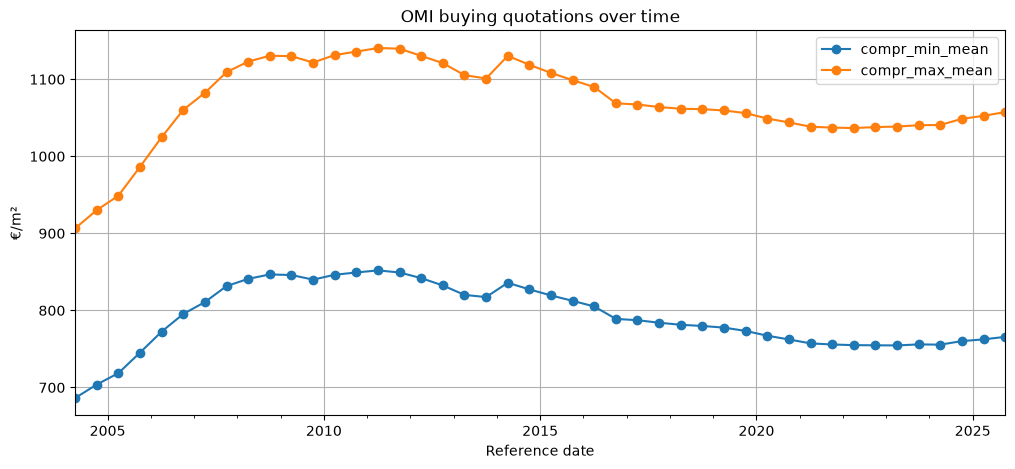

In [129]:
quotation_by_date[
    ["compr_min_mean", "compr_max_mean"]
].plot(
    figsize=(12, 5),
    marker="o",
)

plt.title("OMI buying quotations over time")
plt.xlabel("Reference date")
plt.ylabel("€/m²")
plt.grid(True)
plt.show()

> **Takeaway:** median buying quotations sit around **€750/m²** (midpoint), with a long right tail (max ≈ €25,000/m²) driven by prime locations; median renting quotations are around **€3.05/m²/month**. See `quotation_by_date` for the full time trend.

## 8. Summary & key takeaways

| Dimension | Value |
|---|---|
| Observations | 7,516,495 |
| Variables | 23 |
| Duplicate rows | 0 |
| Time span | 2004-06-30 → 2025-12-31 (44 semesters) |
| Regions | 20 |
| Provinces | 102 |
| Municipalities | 8,220 |
| OMI zone codes | 393 |
| Property types | 19 |
| Property condition states | 3 |
| Missing `Compr_min`/`Compr_max` | 0.02% |
| Missing `Loc_min`/`Loc_max` | 7.28% |
| Invalid buying ranges (`min` > `max`) | 0 |
| Invalid rental ranges (`min` > `max`) | 230 |
| Median buying quotation | ≈ €750/m² |
| Median renting quotation | ≈ €3.05/m²/month |

**Data quality notes for downstream work**
- The dataset is essentially complete and duplicate-free; the main gap is rental quotations, missing for ~7% of observations (properties not typically rented in that zone/type combination).
- The 230 rows with an inverted rental range should be corrected or excluded before modeling.
- `Cod_Tip` → `Descr_Tipologia` and OMI zone codes are consistent identifiers that can safely be used as categorical keys.

**Suggested next steps**
- Build a cleaned, analysis-ready panel (municipality × zone × property type × semester) with outlier handling for the derived midpoint/range features.
- Model the evolution of buying/renting quotations over time and across geography (e.g. regional price convergence, urban vs. rural trends).
- Cross-reference with external data (e.g. income, demographics) for market-driver analysis.